In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path to dataset files: /kaggle/input/eye-diseases-classification


In [ ]:
DATASET_PATH = "/kaggle/input/eye-diseases-classification/dataset"

In [ ]:
!ls "$DATASET_PATH"

cataract  diabetic_retinopathy	glaucoma  normal


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 4

In [ ]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return enhanced

In [ ]:
def segment_blood_vessels(img):
    green = img[:, :, 1]
    blurred = cv2.GaussianBlur(green, (5,5), 0)

    _, vessel_mask = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    vessel_mask = cv2.morphologyEx(vessel_mask, cv2.MORPH_OPEN, kernel)

    return vessel_mask

In [ ]:
def segment_optic_disc(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 5)

    mask = np.zeros_like(gray)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=100,
        param1=50,
        param2=30,
        minRadius=30,
        maxRadius=120
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        x, y, r = circles[0][0]
        cv2.circle(mask, (x, y), r, 255, -1)

    return mask

In [ ]:
def segment_exudates(img, optic_disc_mask):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray[optic_disc_mask == 255] = 0

    _, exudate_mask = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    exudate_mask = cv2.morphologyEx(exudate_mask, cv2.MORPH_OPEN, kernel)

    return exudate_mask


In [ ]:
def combine_segments(img, vessels, optic_disc, exudates):
    combined = np.zeros_like(img)

    combined[vessels == 255] = img[vessels == 255]
    combined[optic_disc == 255] = img[optic_disc == 255]
    combined[exudates == 255] = img[exudates == 255]

    return combined


In [ ]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    enhanced = apply_clahe(img)
    vessels = segment_blood_vessels(enhanced)
    optic_disc = segment_optic_disc(enhanced)
    exudates = segment_exudates(enhanced, optic_disc)

    final_img = combine_segments(enhanced, vessels, optic_disc, exudates)


    final_img = preprocess_input(final_img)

    return final_img

In [ ]:
class RetinalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=8, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_y = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X, y = [], []

        for path, label in zip(batch_x, batch_y):
            img = preprocess_image(path)

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)

            X.append(img)
            y.append(label)

        return np.array(X), np.array(y)

In [ ]:
class_names = [
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "normal"
]

label_map = {cls: idx for idx, cls in enumerate(class_names)}

image_paths = []
labels = []

for cls in class_names:
    folder = os.path.join(DATASET_PATH, cls)
    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(label_map[cls])

labels = np.array(labels)

In [ ]:
train_p, temp_p, train_l, temp_l = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p,
    temp_l,
    test_size=0.5,
    random_state=42,
    stratify=temp_l
)

train_l = to_categorical(train_l, NUM_CLASSES)
val_l   = to_categorical(val_l, NUM_CLASSES)
test_l  = to_categorical(test_l, NUM_CLASSES)

train_gen = RetinalDataGenerator(train_p, train_l, BATCH_SIZE, augment=True)
val_gen   = RetinalDataGenerator(val_p, val_l, BATCH_SIZE)
test_gen  = RetinalDataGenerator(test_p, test_l, BATCH_SIZE)


In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True


x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 14,975,748 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 166s 394ms/step - accuracy: 0.7025 - loss: 0.7361 - val_accuracy: 0.8861 - val_loss: 0.3255
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 123s 336ms/step - accuracy: 0.9125 - loss: 0.2516 - val_accuracy: 0.9066 - val_loss: 0.2606
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 123s 333ms/step - accuracy: 0.9388 - loss: 0.1645 - val_accuracy: 0.9288 - val_loss: 0.2030
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 123s 335ms/step - accuracy: 0.9548 - loss: 0.1165 - val_accuracy: 0.8877 - val_loss: 0.3678
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 124s 337ms/step - accuracy: 0.9548 - loss: 0.1286 - val_accuracy: 0.9241 - val_loss: 0.2200
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 124s 338ms/step - accuracy: 0.9689 - loss: 0.0835 - val_accuracy: 0.9146 - val_loss: 0.3705
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 125s 340ms/step - accuracy: 0.9827 - loss: 0.0556 - val_accuracy: 0.9225 - val_loss: 0.3155
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 126s 342ms/step - accuracy: 0.9790 -

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 357ms/step - accuracy: 0.9273 - loss: 0.4087
Test Accuracy: 0.9272152185440063


79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 293ms/step
Prediction length: 632
True length: 632


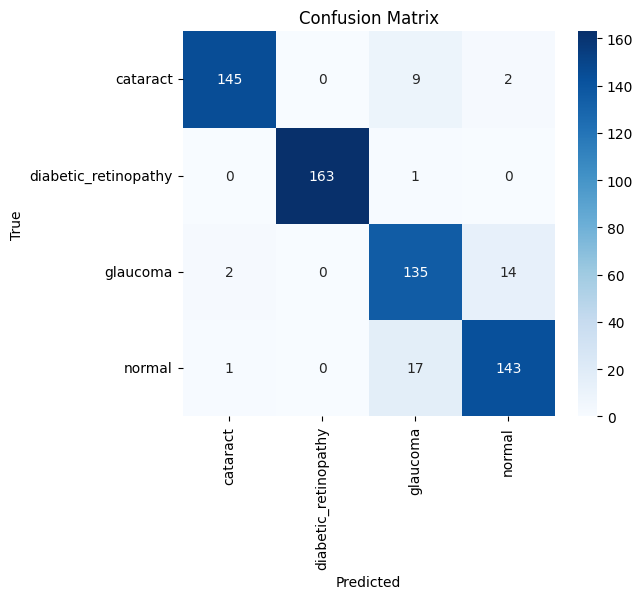


Classification Report:

                      precision    recall  f1-score   support

            cataract     0.9797    0.9295    0.9539       156
diabetic_retinopathy     1.0000    0.9939    0.9969       164
            glaucoma     0.8333    0.8940    0.8626       151
              normal     0.8994    0.8882    0.8938       161

            accuracy                         0.9272       632
           macro avg     0.9281    0.9264    0.9268       632
        weighted avg     0.9295    0.9272    0.9279       632



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_full = np.argmax(test_l, axis=1)


y_true = y_true_full[:len(y_pred)]

print("Prediction length:", len(y_pred))
print("True length:", len(y_true))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)